In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

c:\Users\Jigme\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_excel("Traffic_Collisions 2023-2025.xlsx")
df.head()

,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,585499,GO-20238050463,2023-01-01 05:00:00,January,Sunday,2023,0,D53,0,NO,...,Forest Hill South (101),-79.417003,43.698996,YES,NO,NO,NO,NO,-79.417003,43.698996
1,585500,GO-20238050544,2023-01-01 05:00:00,January,Sunday,2023,21,D43,0,NO,...,Morningside (135),-79.203018,43.791569,YES,NO,NO,NO,NO,-79.203018,43.791569
2,585501,GO-20238050541,2023-01-01 05:00:00,January,Sunday,2023,22,D52,0,NO,...,Kensington-Chinatown (78),-79.399163,43.656119,YES,NO,NO,NO,NO,-79.399163,43.656119
3,585502,GO-20238109784,2023-01-01 05:00:00,January,Sunday,2023,8,D31,0,NO,...,Black Creek (24),-79.508893,43.764550,YES,NO,NO,NO,NO,-79.508893,43.764550
4,585503,GO-20238109995,2023-01-01 05:00:00,January,Sunday,2023,14,D41,0,NO,...,Clairlea-Birchmount (120),-79.287687,43.713318,N/R,N/R,N/R,N/R,N/R,-79.287687,43.713318


In [3]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 205227 entries, 0 to 205226
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   OBJECTID           205227 non-null  int64         
 1   EVENT_UNIQUE_ID    205227 non-null  str           
 2   OCC_DATE           205227 non-null  datetime64[us]
 3   OCC_MONTH          205227 non-null  str           
 4   OCC_DOW            205227 non-null  str           
 5   OCC_YEAR           205227 non-null  int64         
 6   OCC_HOUR           205227 non-null  int64         
 7   DIVISION           205227 non-null  str           
 8   FATALITIES         205227 non-null  int64         
 9   INJURY_COLLISIONS  205227 non-null  str           
 10  FTR_COLLISIONS     205227 non-null  str           
 11  PD_COLLISIONS      205227 non-null  str           
 12  HOOD_158           205227 non-null  str           
 13  NEIGHBOURHOOD_158  205227 non-null  str           
 14 

In [4]:
df.duplicated().sum()   

np.int64(0)

In [5]:
# 1) Make a safe copy
eda = df.copy()

# 2) Ensure correct types
eda["OCC_DATE"] = pd.to_datetime(eda["OCC_DATE"], errors="coerce")
eda["OCC_HOUR"] = pd.to_numeric(eda["OCC_HOUR"], errors="coerce").fillna(0).astype(int).clip(0, 23)

# 3) Build full datetime (date + hour)
eda["occ_datetime"] = eda["OCC_DATE"].dt.floor("D") + pd.to_timedelta(eda["OCC_HOUR"], unit="h")

# 4) Time features (very important for your capstone)
eda["occ_year"] = eda["occ_datetime"].dt.year
eda["occ_month"] = eda["occ_datetime"].dt.month
eda["occ_month_name"] = eda["occ_datetime"].dt.month_name()
eda["occ_day_name"] = eda["occ_datetime"].dt.day_name()
eda["occ_hour"] = eda["occ_datetime"].dt.hour
eda["occ_date_only"] = eda["occ_datetime"].dt.date

# 5) Convert YES/NO flags to 1/0
yes_no_cols = [
    "INJURY_COLLISIONS", "FTR_COLLISIONS", "PD_COLLISIONS",
    "AUTOMOBILE", "MOTORCYCLE", "PASSENGER", "BICYCLE", "PEDESTRIAN"
]

yes_no_cols = [c for c in yes_no_cols if c in eda.columns]

for c in yes_no_cols:
    eda[c] = eda[c].astype(str).str.strip().str.upper().map({"YES": 1, "NO": 0})

# 6) Quick checks
print("EDA shape:", eda.shape)
print("\nConverted YES/NO columns:", yes_no_cols)
print("\nSample rows:")
display(eda[["OCC_DATE", "OCC_HOUR", "occ_datetime", "occ_day_name", "occ_hour"] + yes_no_cols[:3]].head())

print("\nMissing values after conversion:")
print(eda[yes_no_cols].isna().sum())

EDA shape: (205227, 30)

Converted YES/NO columns: ['INJURY_COLLISIONS', 'FTR_COLLISIONS', 'PD_COLLISIONS', 'AUTOMOBILE', 'MOTORCYCLE', 'PASSENGER', 'BICYCLE', 'PEDESTRIAN']

Sample rows:


,OCC_DATE,OCC_HOUR,occ_datetime,occ_day_name,occ_hour,INJURY_COLLISIONS,FTR_COLLISIONS,PD_COLLISIONS
0,2023-01-01 05:00:00,0,2023-01-01 00:00:00,Sunday,0,0,0,1
1,2023-01-01 05:00:00,21,2023-01-01 21:00:00,Sunday,21,0,1,1
2,2023-01-01 05:00:00,22,2023-01-01 22:00:00,Sunday,22,0,0,1
3,2023-01-01 05:00:00,8,2023-01-01 08:00:00,Sunday,8,0,1,0
4,2023-01-01 05:00:00,14,2023-01-01 14:00:00,Sunday,14,0,1,0



Missing values after conversion:
INJURY_COLLISIONS      0
FTR_COLLISIONS         0
PD_COLLISIONS          0
AUTOMOBILE           676
MOTORCYCLE           676
PASSENGER            676
BICYCLE              676
PEDESTRIAN           676
dtype: int64


=== Unexpected raw values in mode columns (before conversion) ===

AUTOMOBILE:
AUTOMOBILE
YES    203014
NO       1537
N/R       676
Name: count, dtype: int64

MOTORCYCLE:
MOTORCYCLE
NO     203593
YES       958
N/R       676
Name: count, dtype: int64

PASSENGER:
PASSENGER
NO     182879
YES     21672
N/R       676
Name: count, dtype: int64

BICYCLE:
BICYCLE
NO     200682
YES      3869
N/R       676
Name: count, dtype: int64

PEDESTRIAN:
PEDESTRIAN
NO     199803
YES      4748
N/R       676
Name: count, dtype: int64

Missing after fill (mode columns only):
AUTOMOBILE    0
MOTORCYCLE    0
PASSENGER     0
BICYCLE       0
PEDESTRIAN    0
dtype: int64

=== Basic Counts ===
Rows: 205227
Unique EVENT_UNIQUE_ID: 205227

=== Year Counts ===
occ_year
2023    67542
2024    70181
2025    67504
Name: count, dtype: int64

=== Month Counts ===
occ_month_name
January      16024
February     16331
March        16110
April        15854
May          17673
June         17660
July         17349
August       1

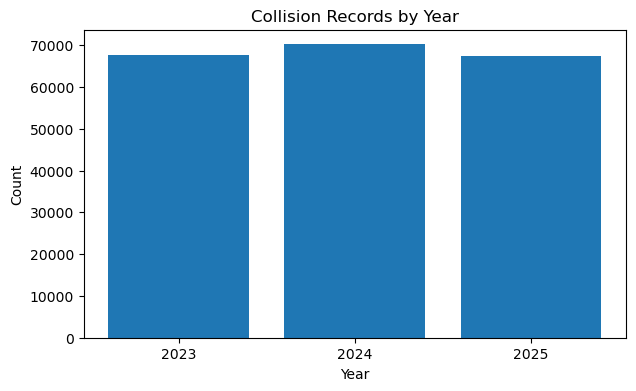

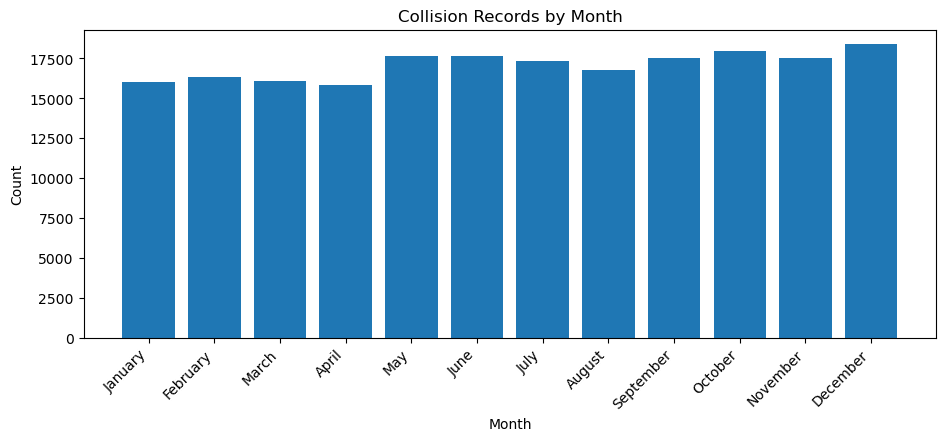

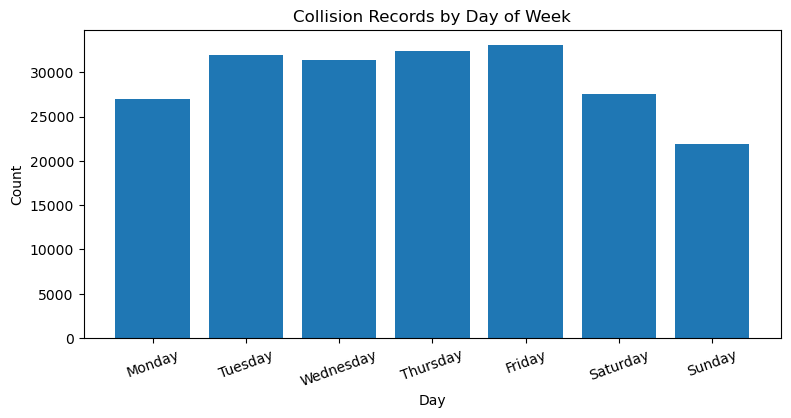

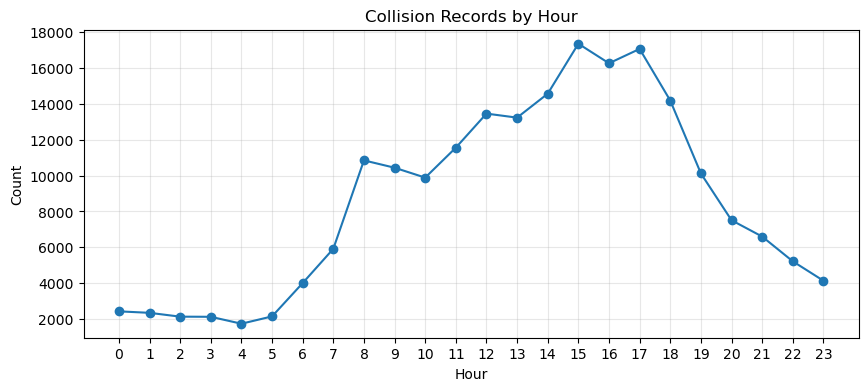

In [6]:
# ----------------------------
# A) Check why 676 became NaN in some YES/NO columns
# ----------------------------
mode_cols = [c for c in ["AUTOMOBILE", "MOTORCYCLE", "PASSENGER", "BICYCLE", "PEDESTRIAN"] if c in df.columns]

print("=== Unexpected raw values in mode columns (before conversion) ===")
for c in mode_cols:
    raw_vals = df[c].astype(str).str.strip().str.upper().value_counts(dropna=False)
    print(f"\n{c}:")
    print(raw_vals.head(10))  # top values

# If blanks mean "NO" in your dataset (common case), fill missing with 0 for EDA

eda[mode_cols] = eda[mode_cols].fillna(0)

print("\nMissing after fill (mode columns only):")
print(eda[mode_cols].isna().sum())

# ----------------------------
# B) Core EDA summaries
# ----------------------------
print("\n=== Basic Counts ===")
print("Rows:", len(eda))
print("Unique EVENT_UNIQUE_ID:", eda["EVENT_UNIQUE_ID"].nunique())

print("\n=== Year Counts ===")
year_counts = eda["occ_year"].value_counts().sort_index()
print(year_counts)

print("\n=== Month Counts ===")
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
month_counts = eda["occ_month_name"].value_counts().reindex(month_order)
print(month_counts)

print("\n=== Day-of-Week Counts ===")
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = eda["occ_day_name"].value_counts().reindex(dow_order)
print(dow_counts)

print("\n=== Hour Counts ===")
hour_counts = eda["occ_hour"].value_counts().sort_index()
print(hour_counts)

print("\n=== YES Rates (%) for binary flags ===")
yes_rates = (eda[yes_no_cols].mean() * 100).round(2).sort_values(ascending=False)
print(yes_rates)


# C) Core plots (Year / Month / Day / Hour)

# 1) By Year
plt.figure(figsize=(7,4))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.title("Collision Records by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# 2) By Month
plt.figure(figsize=(11,4))
plt.bar(month_counts.index, month_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Collision Records by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# 3) By Day of Week
plt.figure(figsize=(9,4))
plt.bar(dow_counts.index, dow_counts.values)
plt.xticks(rotation=20)
plt.title("Collision Records by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

# 4) By Hour
plt.figure(figsize=(10,4))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.title("Collision Records by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

=== Top 15 Divisions ===


,collision_count
DIVISION,
NSA,27938
D42,16423
D32,15703
D41,15227
D55,13298
D33,12882
D43,11648
D14,11597
D22,11548


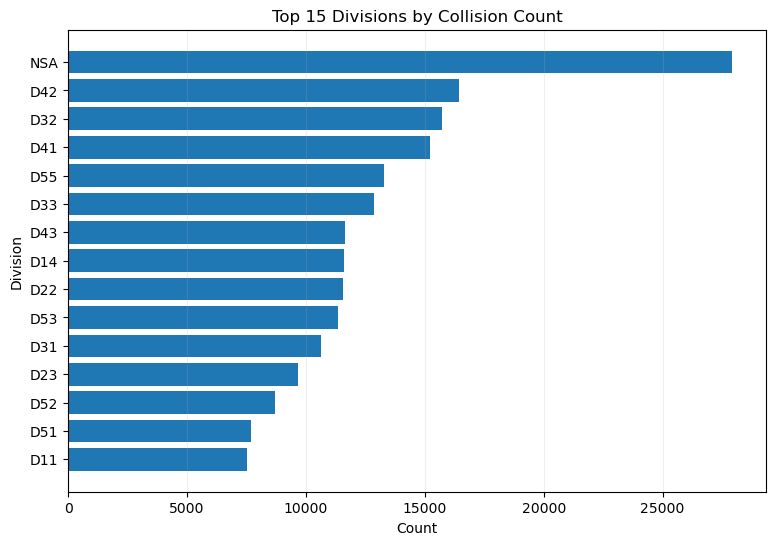


=== Top 20 Neighbourhoods ===


,collision_count
NEIGHBOURHOOD_158,
NSA,32453
Wexford/Maryvale (119),5596
West Humber-Clairville (1),4108
Dorset Park (126),3326
York University Heights (27),3316
Banbury-Don Mills (42),2994
St Lawrence-East Bayfront-The Islands (166),2945
Milliken (130),2894
Woburn North (142),2803


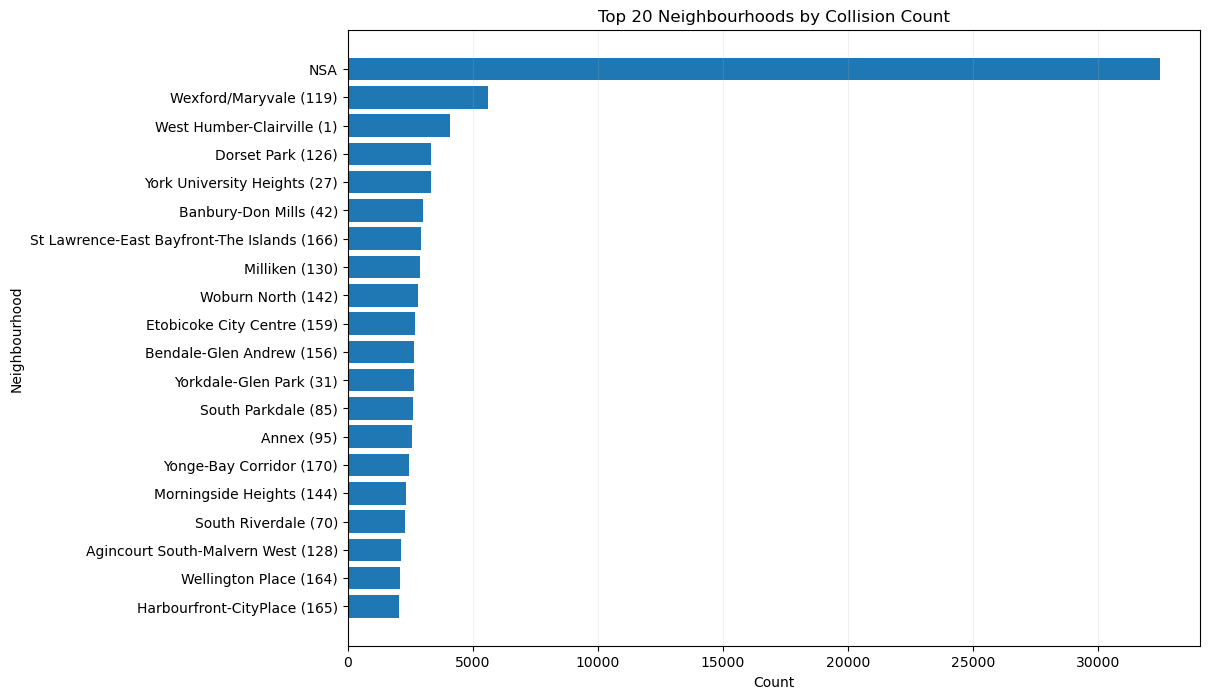


=== Day x Hour table (counts) ===


occ_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
occ_day_name,,,,,,,,,,,,,,,,,,,,,
Monday,297,288,271,266,215,312,560,859,1707,1455,...,1906,2508,2309,2355,1782,1199,865,697,565,405
Tuesday,258,258,193,232,256,338,725,1174,2263,2034,...,2065,2637,2683,2841,2336,1402,1068,857,653,491
Wednesday,239,255,210,192,210,346,728,1067,2149,1872,...,2118,2682,2579,2811,2131,1511,1018,905,688,477
Thursday,252,234,227,261,236,331,742,1212,2076,1896,...,2214,2799,2583,2783,2279,1602,1072,972,718,539
Friday,331,305,268,302,254,335,647,949,1624,1524,...,2390,2851,2608,2717,2307,1801,1375,1204,979,820
Saturday,483,501,484,428,275,242,320,361,586,1002,...,2076,2101,1936,1899,1872,1492,1195,1135,1001,882
Sunday,569,505,480,444,293,243,283,294,440,653,...,1794,1771,1561,1653,1473,1110,915,828,614,522


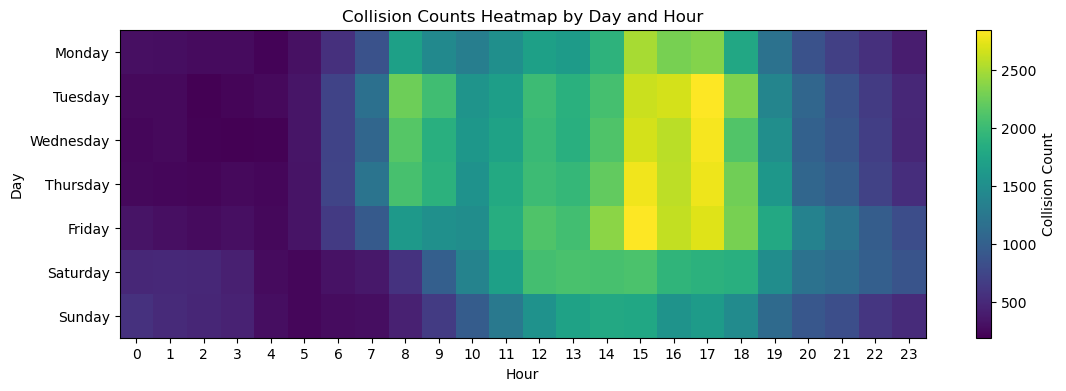


=== Top 10 HOOD_158 x Hour pivot ===


occ_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
HOOD_158,,,,,,,,,,,,,,,,,,,,,
001,58,55,69,57,55,71,139,186,238,181,...,295,332,301,276,232,161,148,136,110,63
027,40,41,39,59,45,57,73,102,174,174,...,247,260,248,255,198,153,98,99,85,56
042,35,27,22,17,14,13,62,91,163,150,...,241,261,257,271,198,153,106,90,62,65
119,56,41,18,23,12,30,82,113,271,218,...,467,507,525,486,430,259,182,168,115,122
126,36,20,14,15,12,13,36,66,128,131,...,284,330,273,317,265,168,120,89,73,63
130,24,18,11,8,4,11,17,56,132,133,...,228,240,233,235,194,172,140,112,83,62
142,31,21,18,12,12,14,39,88,133,124,...,228,267,219,239,220,146,105,84,83,53
159,22,35,24,27,28,30,48,71,90,111,...,233,223,227,217,186,118,76,84,57,42
166,40,30,30,36,15,35,70,81,128,147,...,194,230,266,276,213,164,119,114,112,93


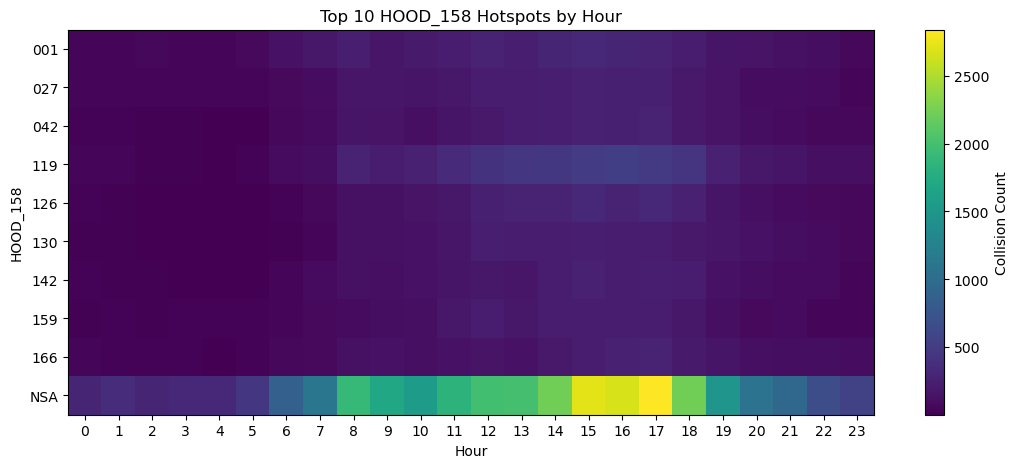


Geo rows after bounds filter: 172774


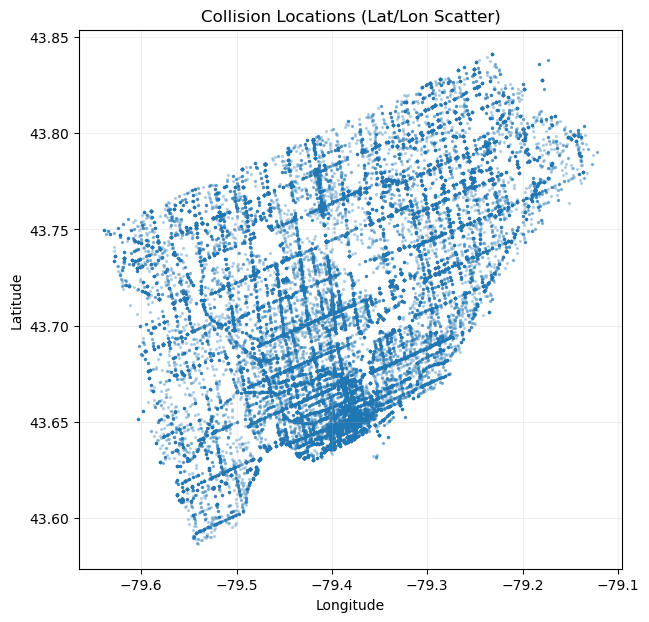

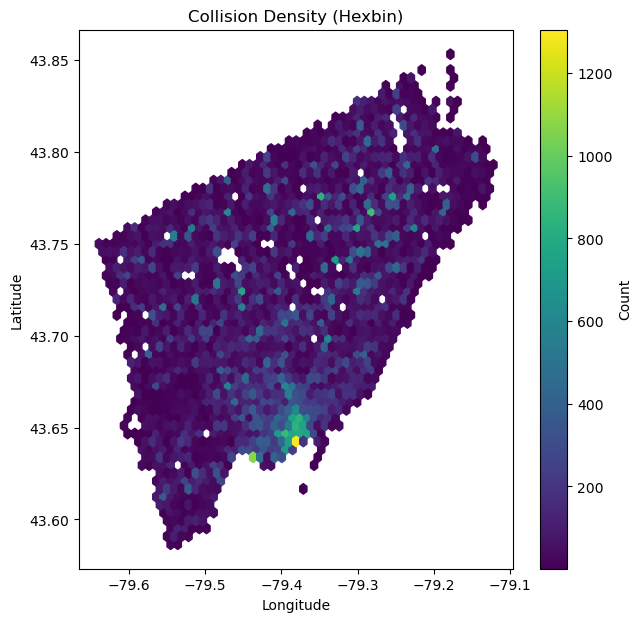


=== Hood Summary (Top 20 by collisions) ===


,HOOD_158,NEIGHBOURHOOD_158,collisions,injury_rate,fatal_rate,ped_rate,bike_rate
158,NSA,NSA,32453,12.34,16.97,0.97,0.53
106,119,Wexford/Maryvale (119),5596,13.15,19.57,1.82,1.04
0,001,West Humber-Clairville (1),4108,18.04,20.76,2.02,0.68
113,126,Dorset Park (126),3326,15.21,17.95,2.10,0.60
23,027,York University Heights (27),3316,17.10,20.69,2.20,1.12
38,042,Banbury-Don Mills (42),2994,13.83,20.04,1.30,0.60
149,166,St Lawrence-East Bayfront-The Islands (166),2945,11.04,19.35,1.73,2.48
116,130,Milliken (130),2894,13.93,22.18,2.04,1.66
125,142,Woburn North (142),2803,15.63,18.23,2.39,0.68
142,159,Etobicoke City Centre (159),2679,13.81,22.88,1.87,0.41


In [7]:
# A) Top Divisions and Neighbourhoods

print("=== Top 15 Divisions ===")
top_div = eda["DIVISION"].astype(str).value_counts().head(15)
display(top_div.to_frame("collision_count"))

plt.figure(figsize=(9,6))
plt.barh(top_div.sort_values().index, top_div.sort_values().values)
plt.title("Top 15 Divisions by Collision Count")
plt.xlabel("Count")
plt.ylabel("Division")
plt.grid(axis="x", alpha=0.2)
plt.show()

print("\n=== Top 20 Neighbourhoods ===")
top_hood = eda["NEIGHBOURHOOD_158"].astype(str).value_counts().head(20)
display(top_hood.to_frame("collision_count"))

plt.figure(figsize=(11,8))
plt.barh(top_hood.sort_values().index, top_hood.sort_values().values)
plt.title("Top 20 Neighbourhoods by Collision Count")
plt.xlabel("Count")
plt.ylabel("Neighbourhood")
plt.grid(axis="x", alpha=0.2)
plt.show()

# B) Day x Hour Heatmap (overall temporal hotspot pattern)
# ----------------------------
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_hour = pd.crosstab(eda["occ_day_name"], eda["occ_hour"]).reindex(dow_order)
day_hour = day_hour.fillna(0)

print("\n=== Day x Hour table (counts) ===")
display(day_hour)

plt.figure(figsize=(13,4))
plt.imshow(day_hour.values, aspect="auto")
plt.colorbar(label="Collision Count")
plt.xticks(range(24), range(24))
plt.yticks(range(len(day_hour.index)), day_hour.index)
plt.title("Collision Counts Heatmap by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

# ----------------------------
# C) Top hotspot neighbourhoods by hour (Top 10 HOODs)
# ----------------------------
top10_hood_codes = eda["HOOD_158"].astype(str).value_counts().head(10).index.tolist()

hood_hour = (
    eda[eda["HOOD_158"].astype(str).isin(top10_hood_codes)]
    .groupby(["HOOD_158", "occ_hour"])
    .size()
    .reset_index(name="count")
)

pivot_hood_hour = hood_hour.pivot(index="HOOD_158", columns="occ_hour", values="count").fillna(0)
pivot_hood_hour = pivot_hood_hour.reindex(columns=range(24), fill_value=0)

print("\n=== Top 10 HOOD_158 x Hour pivot ===")
display(pivot_hood_hour)

plt.figure(figsize=(13,5))
plt.imshow(pivot_hood_hour.values, aspect="auto")
plt.colorbar(label="Collision Count")
plt.xticks(range(24), range(24))
plt.yticks(range(len(pivot_hood_hour.index)), pivot_hood_hour.index.astype(str))
plt.title("Top 10 HOOD_158 Hotspots by Hour")
plt.xlabel("Hour")
plt.ylabel("HOOD_158")
plt.show()

# ----------------------------
# D) Geo EDA (Lat/Lon scatter + density hexbin)
# ----------------------------
geo = eda[["LAT_WGS84", "LONG_WGS84"]].copy()
geo["LAT_WGS84"] = pd.to_numeric(geo["LAT_WGS84"], errors="coerce")
geo["LONG_WGS84"] = pd.to_numeric(geo["LONG_WGS84"], errors="coerce")
geo = geo.dropna()

# Filter to Toronto-ish bounds 
geo = geo[geo["LAT_WGS84"].between(43.0, 44.5) & geo["LONG_WGS84"].between(-80.5, -78.5)]

print("\nGeo rows after bounds filter:", len(geo))

# Sample for faster plotting if large
if len(geo) > 50000:
    geo_plot = geo.sample(50000, random_state=42)
else:
    geo_plot = geo.copy()

# Scatter map
plt.figure(figsize=(7,7))
plt.scatter(geo_plot["LONG_WGS84"], geo_plot["LAT_WGS84"], s=2, alpha=0.25)
plt.title("Collision Locations (Lat/Lon Scatter)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.show()

# Hexbin density 
plt.figure(figsize=(7,7))
plt.hexbin(geo["LONG_WGS84"], geo["LAT_WGS84"], gridsize=55, mincnt=1)
plt.colorbar(label="Count")
plt.title("Collision Density (Hexbin)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# ----------------------------
# E) Top neighbourhoods with injury/fatal rates
# ----------------------------
hood_summary = (
    eda.groupby(["HOOD_158", "NEIGHBOURHOOD_158"], dropna=False)
       .agg(
           collisions=("EVENT_UNIQUE_ID", "count"),
           injury_rate=("INJURY_COLLISIONS", "mean"),
           fatal_rate=("FTR_COLLISIONS", "mean"),
           ped_rate=("PEDESTRIAN", "mean"),
           bike_rate=("BICYCLE", "mean")
       )
       .reset_index()
)

# Convert rates to %
for col in ["injury_rate", "fatal_rate", "ped_rate", "bike_rate"]:
    hood_summary[col] = (hood_summary[col] * 100).round(2)

hood_summary = hood_summary.sort_values("collisions", ascending=False)

print("\n=== Hood Summary (Top 20 by collisions) ===")
display(hood_summary.head(20))

In [8]:
# Check exact and near-NSA values in both columns
for col in ["NEIGHBOURHOOD_158", "HOOD_158"]:
    s = df[col].astype(str)
    print(f"\n=== {col} values containing 'NSA' (raw) ===")
    print(s[s.str.contains("NSA", case=False, na=False)].value_counts(dropna=False))

    print(f"\n=== {col} values after strip+upper containing 'NSA' ===")
    s_clean = s.str.strip().str.upper()
    print(s_clean[s_clean.str.contains("NSA", na=False)].value_counts(dropna=False))


=== NEIGHBOURHOOD_158 values containing 'NSA' (raw) ===
NEIGHBOURHOOD_158
NSA    32453
Name: count, dtype: int64

=== NEIGHBOURHOOD_158 values after strip+upper containing 'NSA' ===
NEIGHBOURHOOD_158
NSA    32453
Name: count, dtype: int64

=== HOOD_158 values containing 'NSA' (raw) ===
HOOD_158
NSA    32453
Name: count, dtype: int64

=== HOOD_158 values after strip+upper containing 'NSA' ===
HOOD_158
NSA    32453
Name: count, dtype: int64


In [9]:
# Show rows where either column looks like NSA
mask_nsa = (
    df["NEIGHBOURHOOD_158"].astype(str).str.strip().str.upper().eq("NSA") |
    df["HOOD_158"].astype(str).str.strip().str.upper().eq("NSA")
)

print("NSA-like rows:", mask_nsa.sum())

display(
    df.loc[mask_nsa, [
        "EVENT_UNIQUE_ID", "NEIGHBOURHOOD_158", "HOOD_158",
        "LAT_WGS84", "LONG_WGS84", "x", "y"
    ]].head(20)
)

NSA-like rows: 32453


,EVENT_UNIQUE_ID,NEIGHBOURHOOD_158,HOOD_158,LAT_WGS84,LONG_WGS84,x,y
7,GO-20238109528,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
9,GO-20238050573,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
10,GO-20238109508,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
13,GO-20238109434,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
14,GO-20238109620,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
15,GO-20238050478,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
18,GO-20238109766,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
19,GO-20238050523,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
21,GO-20238050565,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14
27,GO-20238109786,NSA,NSA,0.0,0.0,5.684342e-14,5.088887e-14


In [10]:
# Count NSA separately in each column
nsa_neigh = df["NEIGHBOURHOOD_158"].astype(str).str.strip().str.upper().eq("NSA").sum()
nsa_hood = df["HOOD_158"].astype(str).str.strip().str.upper().eq("NSA").sum()

print("NSA in NEIGHBOURHOOD_158:", int(nsa_neigh))
print("NSA in HOOD_158:", int(nsa_hood))

# Show distinct raw values that normalize to NSA (helps catch hidden spaces/chars)
for col in ["NEIGHBOURHOOD_158", "HOOD_158"]:
    raw = df[col].astype(str)
    cleaned = raw.str.strip().str.upper()
    vals = raw[cleaned.eq("NSA")].value_counts(dropna=False)
    print(f"\nRaw variants in {col} that become 'NSA':")
    print(vals)

# Coordinate check for NSA rows
mask_nsa = (
    df["NEIGHBOURHOOD_158"].astype(str).str.strip().str.upper().eq("NSA") |
    df["HOOD_158"].astype(str).str.strip().str.upper().eq("NSA")
)

print("\nCoordinate summary for NSA-like rows:")
display(df.loc[mask_nsa, ["LAT_WGS84", "LONG_WGS84", "x", "y"]].describe(include="all"))

NSA in NEIGHBOURHOOD_158: 32453
NSA in HOOD_158: 32453

Raw variants in NEIGHBOURHOOD_158 that become 'NSA':
NEIGHBOURHOOD_158
NSA    32453
Name: count, dtype: int64

Raw variants in HOOD_158 that become 'NSA':
HOOD_158
NSA    32453
Name: count, dtype: int64

Coordinate summary for NSA-like rows:


,LAT_WGS84,LONG_WGS84,x,y
count,32453.0,32453.0,3.245300e+04,3.245300e+04
mean,0.0,0.0,5.684342e-14,5.088887e-14
std,0.0,0.0,6.310984e-30,4.193018e-26
min,0.0,0.0,5.684342e-14,5.088887e-14
25%,0.0,0.0,5.684342e-14,5.088887e-14
50%,0.0,0.0,5.684342e-14,5.088887e-14
75%,0.0,0.0,5.684342e-14,5.088887e-14
max,0.0,0.0,5.684342e-14,5.088887e-14


In [11]:
# Final spatial-clean dataframe for maps / hotspot analysis / forecasting
eda_spatial = eda.copy()

# Clean helper columns
eda_spatial["HOOD_158_clean"] = eda_spatial["HOOD_158"].astype(str).str.strip().str.upper()
eda_spatial["NEIGHBOURHOOD_158_clean"] = eda_spatial["NEIGHBOURHOOD_158"].astype(str).str.strip()

# Ensure coords are numeric
eda_spatial["LAT_WGS84"] = pd.to_numeric(eda_spatial["LAT_WGS84"], errors="coerce")
eda_spatial["LONG_WGS84"] = pd.to_numeric(eda_spatial["LONG_WGS84"], errors="coerce")

# Keep valid spatial rows only
eda_spatial = eda_spatial[
    eda_spatial["LAT_WGS84"].between(43.0, 44.5) &
    eda_spatial["LONG_WGS84"].between(-80.5, -78.5) &
    eda_spatial["HOOD_158_clean"].str.fullmatch(r"\d+", na=False)
].copy()

# Convert HOOD_158 to int for cleaner grouping later (optional)
eda_spatial["HOOD_158_num"] = eda_spatial["HOOD_158_clean"].astype(int)

print("Spatial rows:", len(eda_spatial))
print("Unique HOODs:", eda_spatial["HOOD_158_num"].nunique())
print("Unique neighbourhoods:", eda_spatial["NEIGHBOURHOOD_158_clean"].nunique())

Spatial rows: 172774
Unique HOODs: 158
Unique neighbourhoods: 158


“Records coded as NSA were treated as non-spatial/unknown location entries (e.g., zero coordinates) and excluded from neighbourhood-level hotspot analysis, while retained for citywide temporal trend analysis.”

,collision_count
NEIGHBOURHOOD_158,
Wexford/Maryvale (119),5596
West Humber-Clairville (1),4108
Dorset Park (126),3326
York University Heights (27),3316
Banbury-Don Mills (42),2994
St Lawrence-East Bayfront-The Islands (166),2945
Milliken (130),2894
Woburn North (142),2803
Etobicoke City Centre (159),2679


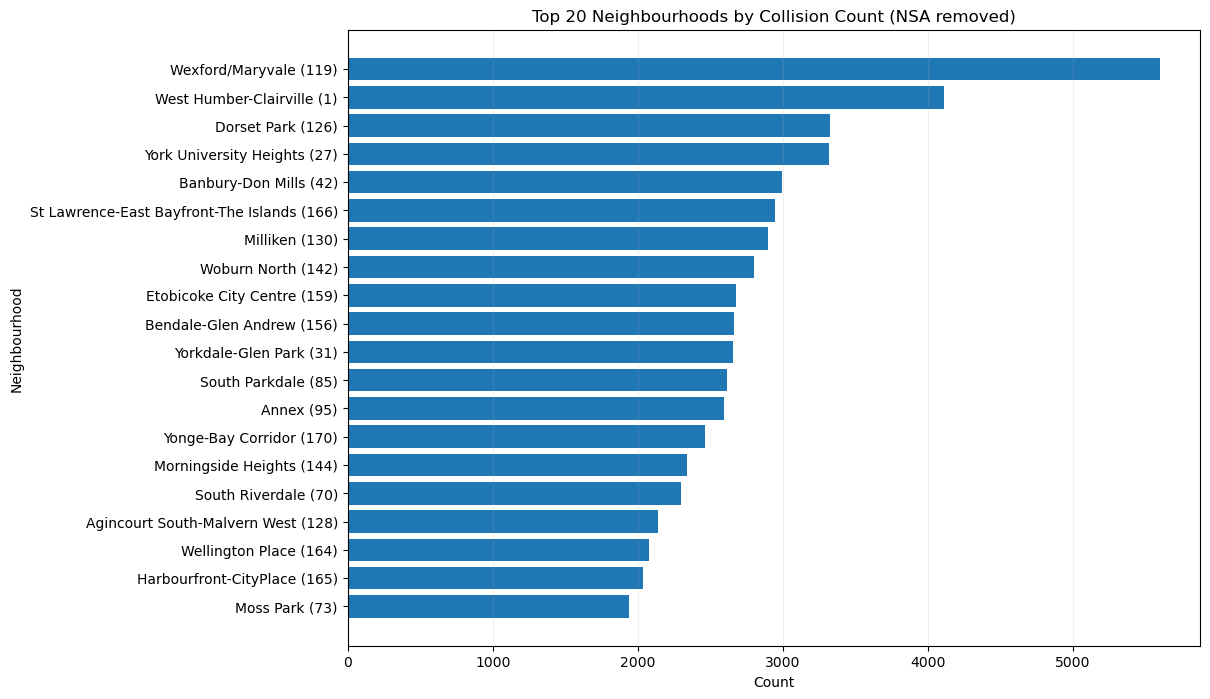

In [12]:
top_hood_spatial = eda_spatial["NEIGHBOURHOOD_158"].value_counts().head(20)

display(top_hood_spatial.to_frame("collision_count"))

plt.figure(figsize=(11,8))
plt.barh(top_hood_spatial.sort_values().index, top_hood_spatial.sort_values().values)
plt.title("Top 20 Neighbourhoods by Collision Count (NSA removed)")
plt.xlabel("Count")
plt.ylabel("Neighbourhood")
plt.grid(axis="x", alpha=0.2)
plt.show()